In [2]:
import pyarrow.parquet as pq

pdf = pq.read_table(
    "/workspace/omnilingual-asr-persian-data-prep/dataset/persian_voice/version=1/corpus=fleurs_yazdi/split=test/language=fa_ir/24_d9829393588a4409a523fe1f92bbcfe3_000000_000000-0.parquet"
)
pdf.schema

text: string
audio_bytes: list<element: int8>
  child 0, element: int8
audio_size: int64
version: dictionary<values=int32, indices=int32, ordered=0>
corpus: dictionary<values=string, indices=int32, ordered=0>
split: dictionary<values=string, indices=int32, ordered=0>
language: dictionary<values=string, indices=int32, ordered=0>

In [4]:
df = pdf.to_pandas()
df

,text,audio_bytes,audio_size,version,corpus,split,language
0,پسته پاش پنوماتیک,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",31576,1,fleurs_yazdi,test,fa_ir
1,سیستم قالب چرب کن روغن پاش,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",50776,1,fleurs_yazdi,test,fa_ir
2,شش پر زیر شاتر قدیمی قطاب,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",57816,1,fleurs_yazdi,test,fa_ir
3,بیست و سه تا دونه دنده مخروطی خمیرقطاب برای ما...,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",107736,1,fleurs_yazdi,test,fa_ir
4,شصت و نه تا بلبرینگ شصت و دو صفر یک برای دستگا...,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",105816,1,fleurs_yazdi,test,fa_ir
5,نازل برنجی چهار هزار,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",31896,1,fleurs_yazdi,test,fa_ir
6,خار گرد,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",24536,1,fleurs_yazdi,test,fa_ir
7,کفی سی و پنج یو سی اف دویست و هفت سی و پنج,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",74136,1,fleurs_yazdi,test,fa_ir
8,سیستم زلفک زن,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",26776,1,fleurs_yazdi,test,fa_ir
9,موتور چهارصد وات,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",33496,1,fleurs_yazdi,test,fa_ir


In [10]:
df[df['text'].str.contains('الک')]

,text,audio_bytes,audio_size,version,corpus,split,language
23,هشتاد و شش عدد الک چوبی برای ماشین مغز خرد کن,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",46296,1,fleurs_yazdi,test,fa_ir
36,الک چوبی,"[102, 76, 97, 67, 0, 0, 0, 34, 16, 0, 16, 0, 0...",31576,1,fleurs_yazdi,test,fa_ir


In [17]:
from datasets import load_dataset
import pandas as pd
df = pd.read_csv("./psbr/Labels.csv")
df.drop(columns=['text'], inplace=True)
df.rename(columns={'audio_path': 'audio', 'audio_duration': 'text'}, inplace=True)
df = df[['audio', 'text']]
df['audio'] = df['audio'].apply(lambda x: f'./psbr/{x}')
df

,audio,text
0,./psbr/Files/audio_1.wav,می‌گم نمی‌خواین طبق نقشه جلو بریم؟ نقشه رو بی‌...
1,./psbr/Files/audio_2.wav,و نقاشی پلیدتم با خودت ببر، جای اون تو این موز...
2,./psbr/Files/audio_3.wav,قروبای باباتون غرق شده چرا جوواب نَمی‌دی؟ السل...
3,./psbr/Files/audio_4.wav,بابا ایشتباه نَمُکُنَم. تو هم این استیک مستیکا...
4,./psbr/Files/audio_5.wav,جاسم باور نمی‌کنم تو یه آتش‌نشان بودی. وِی کوک...
...,...,...
339,./psbr/Files/audio_340.wav,خب یه خورده‌ای پول خرد بذار تو کیفت این اتفاقا...
340,./psbr/Files/audio_341.wav,تو سلبناز طناز شهره‌ی شهر شیراز مرغ هزار و خوش...
341,./psbr/Files/audio_342.wav,امسال اگر آروم بیگیرین کنج خونه‌هاتون، اگه گوش...
342,./psbr/Files/audio_343.wav,از لحاظ زبان‌شناسی یَک عیب دیگر هم به زبان بلو...


In [18]:
from datasets import Dataset, Audio 
hfds = Dataset.from_pandas(df, split='test').cast_column('audio', Audio(sampling_rate=16000))
hfds

Dataset({
    features: ['audio', 'text'],
    num_rows: 344
})

In [19]:
hfds.push_to_hub("AKA-Abdol/part-psbr", split='test', commit_message="test set for Part is up")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/344 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/4 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/datasets/AKA-Abdol/part-psbr/commit/c59e35ea64104fc79fcfb6c89ccfb1dab6ee04d4', commit_message='test set for Part is up', commit_description='', oid='c59e35ea64104fc79fcfb6c89ccfb1dab6ee04d4', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/AKA-Abdol/part-psbr', endpoint='https://huggingface.co', repo_type='dataset', repo_id='AKA-Abdol/part-psbr'), pr_revision=None, pr_num=None)

In [1]:
from fairseq2.data.tokenizers import load_tokenizer
tokenizer = load_tokenizer('omniASR_tokenizer', progress=False)
encoder = tokenizer.create_encoder()
encoder

In [6]:
from pyarrow import parquet as pq 
from glob import glob 

zero_lens_parquets = []
parquets = glob("./dataset/persian_voice/version=1/**/split=dev/**/*.parquet", recursive=True)
for parquet in parquets:
    df = pq.read_table(parquet).to_pandas()
    base_len = len(df)
    print(parquet, 'with len of', base_len)
    # df = df[df['text'].apply(lambda x: all([ 3 <= c <= 4 for c in encoder(x).tolist()]))]
    df = df[df['text'].str.contains('وامیساد', regex=False)]
    if len(df) > 0:
        print('found', len(df), 'rows with empty text in', parquet)
        break
        zero_lens_parquets.append(parquet)
    

./dataset/persian_voice/version=1/corpus=common_voice_17/split=dev/language=fa_ir/10_dadf9dc63a98411f84a1be0fabb8a44c_000000_000000-0.parquet with len of 2889
./dataset/persian_voice/version=1/corpus=youtube/split=dev/language=fa_ir/10_d024ab0507ac47fea0e3642f8bb3cc5b_000000_000000-0.parquet with len of 10486
./dataset/persian_voice/version=1/corpus=youtube/split=dev/language=fa_ir/10_d024ab0507ac47fea0e3642f8bb3cc5b_000001_000000-0.parquet with len of 10030
./dataset/persian_voice/version=1/corpus=youtube/split=dev/language=fa_ir/10_d024ab0507ac47fea0e3642f8bb3cc5b_000002_000000-0.parquet with len of 10006
./dataset/persian_voice/version=1/corpus=youtube/split=dev/language=fa_ir/10_d024ab0507ac47fea0e3642f8bb3cc5b_000003_000000-0.parquet with len of 10023
./dataset/persian_voice/version=1/corpus=youtube/split=dev/language=fa_ir/10_d024ab0507ac47fea0e3642f8bb3cc5b_000004_000000-0.parquet with len of 10027
./dataset/persian_voice/version=1/corpus=youtube/split=dev/language=fa_ir/10_d024

In [ ]:
print(zero_lens_parquets)

[]


In [7]:
import pandas as pd 
df = pd.read_parquet('./dataset/persian_voice/version=1/corpus=filimo/split=dev/language=fa_ir/24_acda39fac2a74b1fa5e59059641a8afc_000000_000000-0.parquet', engine='pyarrow')

In [16]:
[12, 3, 3, 42, 3].count(3)

3

In [17]:
tokenizer.vocab_info

VocabularyInfo(size=9812, unk_idx=3, bos_idx=0, eos_idx=2, pad_idx=1, boh_idx=None, eoh_idx=None)

In [21]:
for t in df['text'].tolist():
    encoded = encoder(t).tolist()
    if encoded.count(3) > (len(encoded) // 10):
        print(t, encoder(t))

بی‌تربیت tensor([6223, 6021,    3, 4919, 8039, 6223, 6021, 4919])
بسم‌الله tensor([6223, 9391, 6595,    3, 9239, 1736, 1736, 5663])
الله‌اکبر tensor([9239, 1736, 1736, 5663,    3, 9239, 2112, 6223, 8039])
بسم‌الله tensor([6223, 9391, 6595,    3, 9239, 1736, 1736, 5663])
نمی‌خواد tensor([9457, 6595, 6021,    3, 9018, 2570, 9239, 4470])
به‌به tensor([6223, 5663,    3, 6223, 5663])
الان می‌آم می‌آم tensor([9239, 1736, 9239, 9457,    4, 6595, 6021,    3, 5914, 6595,    4, 6595,
        6021,    3, 5914, 6595])
پس نمی‌شه tensor([9401, 9391,    4, 9457, 6595, 6021,    3, 6523, 5663])
به‌به به‌به tensor([6223, 5663,    3, 6223, 5663,    4, 6223, 5663,    3, 6223, 5663])
می‌ری می‌شنی تو tensor([6595, 6021,    3, 8039, 6021,    4, 6595, 6021,    3, 6523, 9457, 6021,
           4, 4919, 2570])
به‌به به‌به tensor([6223, 5663,    3, 6223, 5663,    4, 6223, 5663,    3, 6223, 5663])
می‌شنوی tensor([6595, 6021,    3, 6523, 9457, 2570, 6021])
می‌دونم tensor([6595, 6021,    3, 4470, 2570, 9457, 6595])


In [9]:
import re
chars_to_mapping = {
    "ك": "ک",
    "دِ": "د",
    "بِ": "ب",
    "زِ": "ز",
    "ذِ": "ذ",
    "شِ": "ش",
    "سِ": "س",
    "ى": "ی",
    "ي": "ی",
    "أ": "ا",
    "ؤ": "و",
    "ے": "ی",
    "ۀ": "ه",
    "ﭘ": "پ",
    "ﮐ": "ک",
    "ﯽ": "ی",
    "ﺎ": "ا",
    "ﺑ": "ب",
    "ﺘ": "ت",
    "ﺧ": "خ",
    "ﺩ": "د",
    "ﺱ": "س",
    "ﻀ": "ض",
    "ﻌ": "ع",
    "ﻟ": "ل",
    "ﻡ": "م",
    "ﻢ": "م",
    "ﻪ": "ه",
    "ﻮ": "و",
    "ﺍ": "ا",
    "ة": "ه",
    "ﯾ": "ی",
    "ﯿ": "ی",
    "ﺒ": "ب",
    "ﺖ": "ت",
    "ﺪ": "د",
    "ﺮ": "ر",
    "ﺴ": "س",
    "ﺷ": "ش",
    "ﺸ": "ش",
    "ﻋ": "ع",
    "ﻤ": "م",
    "ﻥ": "ن",
    "ﻧ": "ن",
    "ﻭ": "و",
    "ﺭ": "ر",
    "ﮔ": "گ",
    "\u202b": " ",
    "\u200c": " ",
    "\u200d": " ",
    "\u200e": " ",
    "\u200f": " ",
    "\ufeff": " ",
    "\u200b": " ",
    '\u200B': " ",  # Zero-Width Space (the problematic one: \xe2\x80\xab)
    '\u200E': " ",  # Left-to-Right Mark
    '\u200F': " ",  # Right-to-Left Mark
    '\uFEFF': " ",  # Zero-Width No-Break Space (BOM)
    '\u2060': " ",  # Word Joiner
    '\u2061': " ",  # Function Application
    '\u2062': " ",  # Invisible Times
    '\u2063': " ",  # Invisible Separator
    '\u2064': " ",  # Invisible Plus
    '\u180E': " ",  # Mongolian Vowel Separator
    '\u2000': " ",  # En Quad
    '\u2001': " ",  # Em Quad
    '\u2002': " ",  # En Space
    '\u2003': " ",  # Em Space
    '\u2004': " ",  # Three-Per-Em Space
    '\u2005': " ",  # Four-Per-Em Space
    '\u2006': " ",  # Six-Per-Em Space
    '\u2007': " ",  # Figure Space
    '\u2008': " ",  # Punctuation Space
    '\u2009': " ",  # Thin Space
    '\u200A': " ",  # Hair Space
    '♫': "",  # Musical note
    '♬': "",  # Musical notes
    '♪': "",  # Musical note
    '♩': "",  # Musical note
    '♭': "",  # Flat
    '♯': "",  # Sharp
    '♮': "",  # Natural
}
def multiple_replace(text, chars_to_mapping):
    sorted_keys = sorted(chars_to_mapping.keys(), key=len, reverse=True)
    pattern = "|".join(map(re.escape, sorted_keys))
    return re.sub(pattern, lambda m: chars_to_mapping[m.group()], str(text))

b''

In [12]:
from pyarrow import parquet as pq
from glob import glob
parquets = glob('/workspace/omnilingual-asr-persian-data-prep/dataset/persian_voice/version=1/corpus=filimo/**/*.parquet', recursive=True)
for file_path in parquets:
    print(file_path)
    df = pq.read_table(file_path).to_pandas()
    df = df[df['text'].str.contains('\u200c', regex=False)]
    if len(df) > 0:
        df['norm_text'] = df['text'].apply(lambda s: multiple_replace(s, chars_to_mapping))
        print(df[['text', 'norm_text']])
        break

/workspace/omnilingual-asr-persian-data-prep/dataset/persian_voice/version=1/corpus=filimo/split=train/language=fa_ir/17_87d0de7a819342aca6d1ec299f03b886_000000_000000-0.parquet


                                                    text  \
10                 مائده و میثم نمی‌تون با هم ازدواج کنن   
22                 اما در مرحله‌ی فینال چه اتفاقی میوفته   
26                 یک دقیقه و سی ثانیه هم بهت فرصت می‌دم   
28           دیواراش نشست کرده همسایه‌ها تخلیه کردن رفتن   
29                      می‌گم همه باید با هم انجامش بدیم   
...                                                  ...   
10032                         فردا شب مافیا می‌خواد بزنه   
10036  با این شروع نمی‌کنن با این تموم می‌کنن فیلی فیشیا   
10038                    از وقتی‌که شروع شد به صحبت کردن   
10039                   دیاکو جان خواهش می‌کنم دیاکو جان   
10043                                تو می‌گی بی‌عرضه‌ام   

                                               norm_text  
10                 مائده و میثم نمی تون با هم ازدواج کنن  
22                 اما در مرحله ی فینال چه اتفاقی میوفته  
26                 یک دقیقه و سی ثانیه هم بهت فرصت می دم  
28           دیواراش نشست کرده همسایه ها تخ

In [104]:
multiple_replace('احسان\u200Bسلام', chars_to_mapping).encode('utf-8')

b'\xd8\xa7\xd8\xad\xd8\xb3\xd8\xa7\xd9\x86 \xd8\xb3\xd9\x84\xd8\xa7\xd9\x85'

In [ ]:
encoder('.')

In [46]:
from fairseq2.data.tokenizers import load_tokenizer
tokenizer = load_tokenizer('omniASR_tokenizer', progress=False)
tokenizer

In [57]:
encoder = tokenizer.create_encoder()
encoder('♬ چزا؟').tolist()

[3, 4, 5532, 4707, 9239, 3]

In [ ]:
! pip install matplotlib

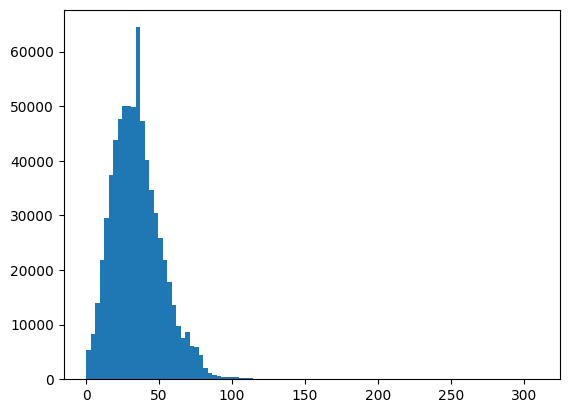

In [6]:
from matplotlib import pyplot as plt 
plt.hist(text_len, bins=100)
plt.show()

In [8]:
text_len.index(0)


7180

In [2]:
import pyarrow as pa
arr = pa.array(["a", "b", "c", None, "e", "f"])
indices = pa.array([0, None, 4, 3])
arr.take([1])

[
  "b"
]

In [4]:
[i for i, t in enumerate(['', ' ', '']) if t.strip() != ""]

[]

In [6]:
pa.Table.from_arrays([pa.array([], type=col.type) for col in arr.itercolumns()], names=arr.column_names)

AttributeError: 'pyarrow.lib.StringArray' object has no attribute 'itercolumns'

In [ ]:
import re
def remove_non_text_characters(text: str) -> str:
    pattern = r'[^\u0600-\u06FF\u0750-\u077F\u08A0-\u08FF\uFB50-\uFDFF\uFE70-\uFEFF\u200C\u200Da-zA-Z0-9\s]'
    text = re.sub(pattern, '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
text = ' ییشسی !٬٫﷼*)﷼(٪ـ*٫٬(ابپت ث جچحخد ذرزژسشص‌ضطظعغفقک لمنوهی !۱۲۳۴۵۶۷۸!۹۱۰! ؟abcdefgh i j klmnopqrstuvwxyz 1234567890 -=/'':: @%'
remove_non_text_characters(text)

'ییشسی ٬٫﷼﷼٪ـ٫٬ابپت ث جچحخد ذرزژسشص\u200cضطظعغفقک لمنوهی ۱۲۳۴۵۶۷۸۹۱۰ ؟abcdefgh i j klmnopqrstuvwxyz 1234567890'

In [4]:
if '‌'.replace('\u200c', ' ') in 'رفته‌ای': print('shiit')

In [5]:
'‌'.replace('\u200c', ' ').encode('utf-8')

b' '